<a href="https://colab.research.google.com/github/Alshigy1981/PlanarRobot-PPO-Point-to-Point-Navigation-with-Gymnasium-Stable-Baselines3/blob/main/Predicting_Electrical_Energy_Output_Using_Environmental_Factors.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Predicting Electrical Energy Output Using Environmental Factors

# Temperature (AT), Ambient Pressure (AP), Relative Humidity (RH) and Exhaust Vacuum (V) to predict the net hourly electrical energy output (EP)

In [5]:
import pandas as pd
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt


In [6]:
# Load data
data = pd.read_excel('Folds5x2_pp.xlsx')

# Preprocessing
X = data[['AT', 'AP', 'RH', 'V']]
y = data['PE']

# Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=0)


In [7]:
model = tf.keras.Sequential([
    tf.keras.layers.Dense(32, activation='relu', input_shape=(X_train.shape[1],)),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(1)
])

model.compile(optimizer='adam', loss='mean_squared_error')


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [8]:
model.fit(X_train, y_train, epochs=100, batch_size=32, validation_split=0.2, verbose=1)


Epoch 1/100
192/192 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 196538.1406 - val_loss: 167894.1719
Epoch 2/100
192/192 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 95472.1641 - val_loss: 32394.8379
Epoch 3/100
192/192 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 18781.3281 - val_loss: 12559.5537
Epoch 4/100
192/192 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 9843.7803 - val_loss: 6884.0942
Epoch 5/100
192/192 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5208.5366 - val_loss: 3396.2981
Epoch 6/100
192/192 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 2638.0549 - val_loss: 1711.1019
Epoch 7/100
192/192 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1438.9971 - val_loss: 968.7928
Epoch 8/100
192/192 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 880.8245 - val_loss: 619.1304
Epoch 9/100
192/192 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 595.5228 - val_loss: 436.6581
Epoch 10/100
192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 425.2354 - val_loss: 311.5227
Epoch 11/100
192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 314.39

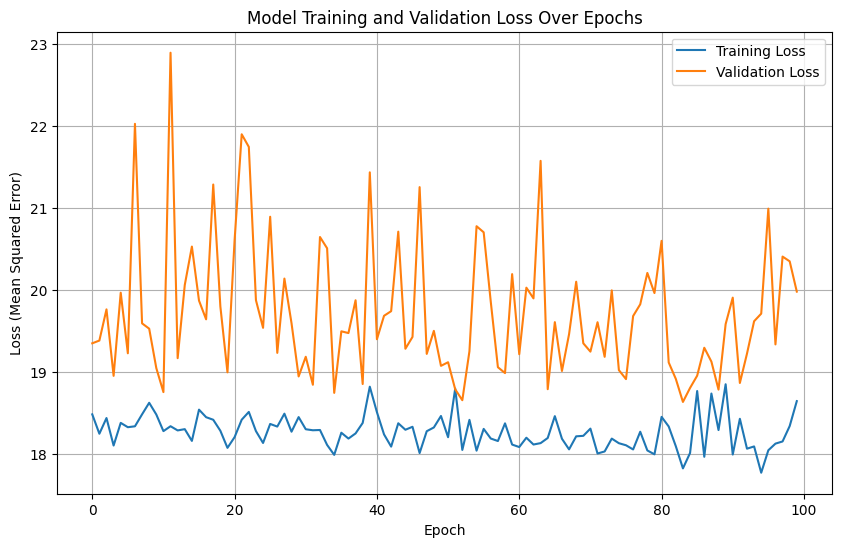

In [11]:
history = model.fit(X_train, y_train, epochs=100, batch_size=32, validation_split=0.2, verbose=0)

plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Training and Validation Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss (Mean Squared Error)')
plt.legend()
plt.grid(True)
plt.show()

In [9]:
# Predictions
predictions = model.predict(X_test).flatten()

# Evaluation
mae = mean_absolute_error(y_test, predictions)
mse = mean_squared_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print(f'Mean Absolute Error: {mae}')
print(f'Mean Squared Error: {mse}')
print(f'R2 Score: {r2}')


60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Mean Absolute Error: 3.3227188426050644
Mean Squared Error: 17.251075544371744
R2 Score: 0.9410195110687514


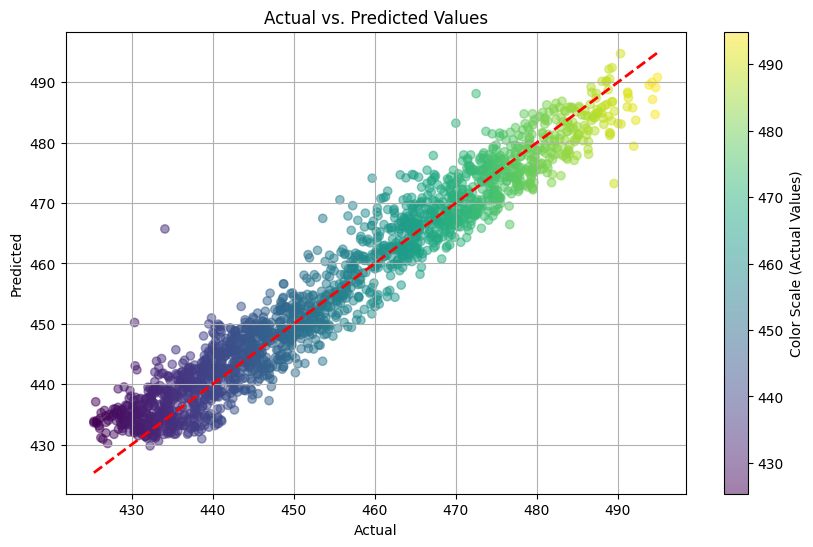

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

# Scatter plot with a color map
plt.scatter(y_test, predictions, c=y_test, alpha=0.5, cmap='viridis')
plt.colorbar().set_label('Color Scale (Actual Values)')

# Red line for perfect predictions
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--', lw=2)

plt.title('Actual vs. Predicted Values')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.grid(True)

plt.show()
